# Confinement label reconciliation

Kevin Gill’s workbook is an exact subset of Jalal’s table. BES-time labels agree on their shared assessed time; one pair of Kevin’s own clips conflicts. These are dependent imported targets, not independent ground truth.

Read-only analysis of `runs/labeler/confinement/v1`, created by `python -m labeler.confinement labels`. Source and output SHA-256 hashes are in `labels.json`. Times are milliseconds; all intervals are half-open. The detector task uses fully covered, single-state 50 ms bins, separately from the paper’s 10 ms review task.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from labeler.confinement import run_directory
from labeler.confinement.labels import digest, merge_intervals
run_dir = run_directory()
summary = json.loads((run_dir / "labels.json").read_text())
for filename, expected in summary["output_hashes"].items():
    assert digest(run_dir / filename) == expected, filename
source = pd.read_csv(run_dir / "source_intervals.csv")
merged = pd.read_csv(run_dir / "merged_intervals.csv")
targets = pd.read_csv(run_dir / "targets.csv")
figures = run_dir / "figures"
figures.mkdir(exist_ok=True)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

## Source dependence

Each annotation is counted at interval grain, with overlapping copies deduplicated before merging. Exact workbook copying prevents interpreting agreement as independent inter-reader reliability.

In [2]:
keys = ["shot", "t_start", "t_end", "regime"]
jalal = source.loc[source.source == "jalal", keys]
workbook = source.loc[source.source == "kevin_workbook", keys]
exact = workbook.merge(jalal, on=keys, how="inner", validate="one_to_one")
assert len(exact) == len(workbook)
print(f"Exact workbook intervals in Jalal: {len(exact)}/{len(workbook)}")
pd.DataFrame(summary["source_stats"]).T

Exact workbook intervals in Jalal: 1958/1958


,shots,intervals
jalal,428,1964
kevin_bes,82,171
kevin_workbook,426,1958


## Agreement over assessed overlap

Duration matrices compare the same shot clock. No agreement is assigned outside both sources’ annotation coverage. The file class ordering L/H/QH/WP is supported by workbook headers and the unique highest agreement permutation; HDF files themselves contain no class names.

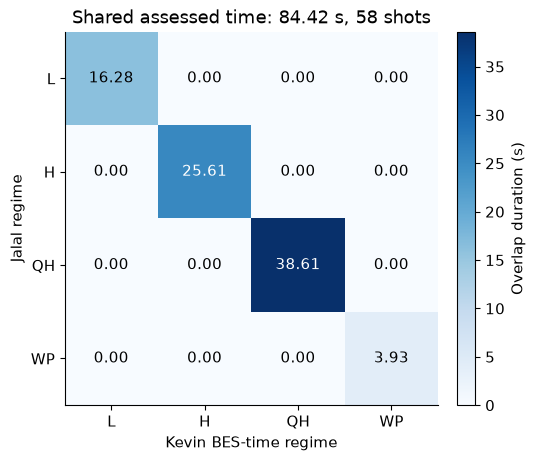

In [3]:
comparison = summary["comparisons"]["jalal vs kevin_bes"]
matrix = np.array(comparison["duration_confusion_ms"]) / 1000
fig, ax = plt.subplots(figsize=(5.2, 4.5), layout="constrained")
image = ax.imshow(matrix, cmap="Blues", vmin=0)
ax.set(xticks=range(4), yticks=range(4), xticklabels=summary["modes"], yticklabels=summary["modes"], xlabel="Kevin BES-time regime", ylabel="Jalal regime", title=f"Shared assessed time: {matrix.sum():.2f} s, {comparison['overlap_shots']} shots")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center", color="white" if matrix[i,j] > matrix.max()/2 else "black")
fig.colorbar(image, ax=ax, label="Overlap duration (s)")
fig.savefig(figures / "source_agreement.png", dpi=180)
fig.savefig(figures / "source_agreement.pdf")
plt.show()

## Conflicts and missing input

QH and WP remain distinct. H/L source disagreements are unknown for training. Empty label clips assert no regime; truncated BES data are unavailable even when their separate labels are readable.

In [4]:
conflicts = pd.read_csv(run_dir / "conflicts.csv")
print(conflicts[["shot", "t_start", "t_end", "regimes", "sources"]].to_string(index=False))
print("Empty time-label files:", [Path(s["path"]).name for s in summary["sources"] if s.get("empty")])
print("Unreadable signal copies:", [s["name"] for s in summary["duplicate_signal_clips"] if not s["readable"]])

  shot  t_start  t_end regimes   sources
189379   3198.0 3450.0     H|L kevin_bes
Empty time-label files: ['bes_signals_192007at1885.hdf5']
Unreadable signal copies: ['bes_signals_149993at4172.hdf5']


## Training balance and held-out support

Targets need complete unambiguous 50 ms coverage. Partial and transition bins remain inspectable but are not fitted. Only training receives equal H/L mass, with equal shot weight within each class. Natural validation/test prevalence is retained. Support below precedes diagnostic availability exclusion.

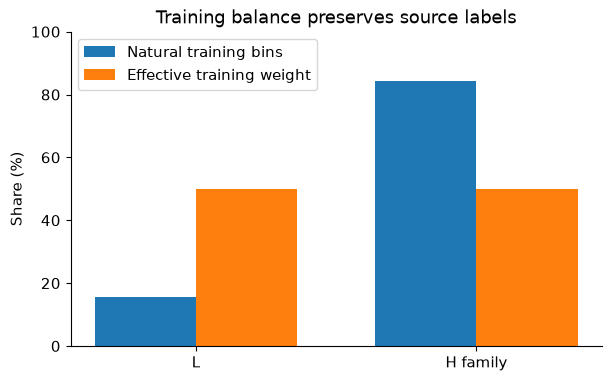

shots  bins
split label             
test  0         17   434
      1         67  2884
train 0         82  1803
      1        274  9740
val   0         17   338
      1         58  2323

In [5]:
known = targets.loc[targets.label >= 0]
train = known.loc[known.split == "train"]
weighted = train.groupby("label").train_weight.sum().reindex([0,1])
assert np.isclose(weighted.iloc[0], weighted.iloc[1])
assert targets.loc[targets.split != "train", "train_weight"].eq(0).all()
fig, ax = plt.subplots(figsize=(6, 3.7), layout="constrained")
raw = train.label.value_counts().reindex([0,1], fill_value=0)
ax.bar(np.arange(2)-0.18, raw/raw.sum()*100, width=.36, label="Natural training bins")
ax.bar(np.arange(2)+0.18, weighted/weighted.sum()*100, width=.36, label="Effective training weight")
ax.set(xticks=[0,1], xticklabels=["L", "H family"], ylabel="Share (%)", ylim=(0,100), title="Training balance preserves source labels")
ax.legend()
fig.savefig(figures / "training_balance.png", dpi=180)
fig.savefig(figures / "training_balance.pdf")
plt.show()
known.groupby(["split","label"]).agg(shots=("shot","nunique"), bins=("shot","size"))

## Scope of the result

The union has 448 shots and 435 with fully covered known bins. No cross-source conflict is found; the sole internal conflict is 252 ms on shot 189379. This audit does not validate labels against independently reviewed plasma evidence. A stronger detector must be tested on available diagnostics with disjoint shots, natural prevalence, matched comparators and missing-modality ablations. Reviewed ELM labels provide a separate consistency study; QH/ELM overlaps flag inspection candidates rather than automatically correcting either source.

## Confinement–ELM consistency

The revised ELM review covers only one confinement shot: the 300 ms QH interval on 192751 is assessed as non-ELMing. A separate original-onset archive gives unresolved QH/onset candidates on fifteen shots; this is a consistency audit, not independent ground truth or a cross-regime association study. Unknown ELM time stays unassessed. Run `python -m labeler.confinement elm --legacy` to create the pinned study first.

In [6]:
study_dir = run_dir / "elm_study"
study = json.loads((study_dir / "study.json").read_text())
assert study["confinement_sha256"] == digest(run_dir / "merged_intervals.csv")
for filename, expected in study["output_hashes"].items():
    assert digest(study_dir / filename) == expected, filename
print("Shared revised-review shots:", study["common_reviewed_shots"])
pd.DataFrame(study["legacy_onset_rates"]["0"])[["regime", "shots", "exposure_s", "onsets", "onset_positive_shots", "onsets_per_second"]]

Shared revised-review shots: [192751]


,regime,shots,exposure_s,onsets,onset_positive_shots,onsets_per_second
0,L,18,5.043948,0,0,0.000000
1,H,0,0.000000,0,0,NaN
2,QH,69,71.216071,60,15,0.842506
3,WP,65,91.520799,43,20,0.469839


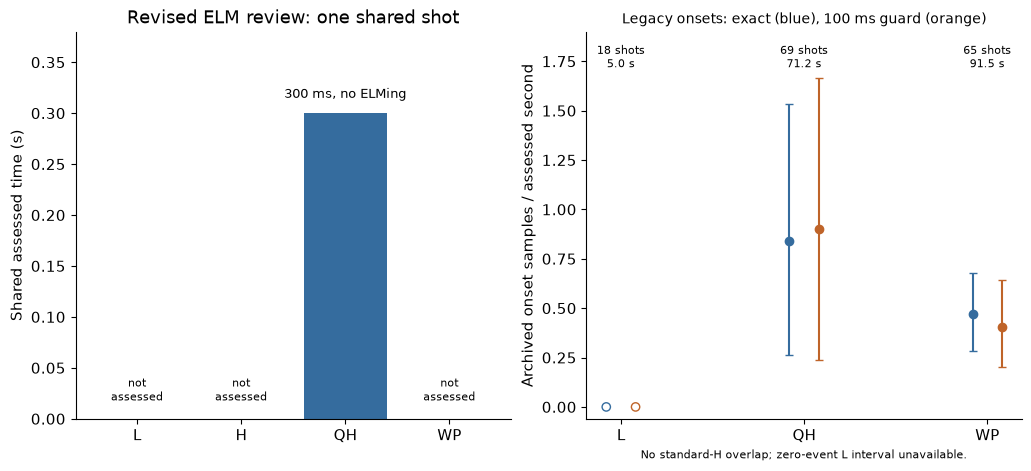

In [7]:
fig, axes = plt.subplots(1,2,figsize=(10.2,4.6),layout="constrained")
left,right=axes
left.bar(["L","H","QH","WP"],[r["assessed_ms"]/1000 for r in study["reviewed_occupancy"]["0"]],color="#356c9e")
left.set(ylabel="Shared assessed time (s)",title="Revised ELM review: one shared shot",ylim=(0,.38))
left.text(2,.315,"300 ms, no ELMing",ha="center",fontsize=9)
for i in [0,1,3]:
    left.text(i,.018,"not\nassessed",ha="center",fontsize=8)
positions={"L":0,"QH":1,"WP":2}
for offset,key,color in [(-.08,"0","#356c9e"),(.08,"100","#bf6429")]:
    for row in study["legacy_onset_rates"][key]:
        if row["regime"]=="H" or row["onsets_per_second"] is None:
            continue
        x=positions[row["regime"]]+offset
        rate=row["onsets_per_second"]
        ci=row["rate_ci95_shot_bootstrap"]
        right.scatter([x],[rate],color=color,facecolors="none" if row["onsets"]==0 else color)
        if ci:
            right.errorbar(x,rate,yerr=[[rate-ci[0]],[ci[1]-rate]],fmt="none",color=color,capsize=3)
right.set(xticks=[0,1,2],xticklabels=["L","QH","WP"],ylabel="Archived onset samples / assessed second",title="Legacy onsets: exact (blue), 100 ms guard (orange)",ylim=(-.06,1.9),xlabel="No standard-H overlap; zero-event L interval unavailable.")
right.xaxis.label.set_fontsize(8)
right.title.set_fontsize(10)
for i,row in enumerate([r for r in study["legacy_onset_rates"]["0"] if r["regime"]!="H"]):
    annotation = str(row["shots"]) + " shots\n" + format(row["exposure_s"], ".1f") + " s"
    right.text(i,1.72,annotation,ha="center",fontsize=8)
fig.savefig(figures / "elm_consistency.png",dpi=180)
fig.savefig(figures / "elm_consistency.pdf")
plt.show()

The revised and legacy panels measure different quantities and have different denominators. Original onset annotations overlap nominal QH intervals on 15 shots; 51 of 60 flagged onset samples on 11 shots remain outside a 100 ms phase-boundary exclusion. These candidates need aligned independent signal review. The revised review alone supports no multi-regime conclusion.

## Frozen diagnostic-summary detector

Selection uses validation only, with the primary full model declared before test.
The eligible test has 28 shots and 1,403 bins (103 L bins on five shots); only
three shots contribute more than one L bin. Equal class/shot weights apply to
training alone, after diagnostic exclusions. Unknown measurements stay missing.
The no-BES and forced-removal results concern BES absence specifically. CO2 and
spectral utility are not established. The original H2 bar still fails; these
results are exploratory against dependent imported supervision.


,model,shots,bins,F1_L,F1_H,macro_F1,balanced_accuracy
0,full,28,1403,0.9254,0.9942,0.9598,0.9495
1,no_bes,28,1403,0.9300,0.9946,0.9623,0.9499
2,dalpha_nbi,28,1403,0.7952,0.9801,0.8876,0.9625
3,bes_only,26,614,0.5000,0.9418,0.7209,0.8925
4,full_forced_no_bes,28,1403,0.9347,0.9950,0.9648,0.9503


Two-class bootstrap valid: 1993 / 2000
F1_L 95% interval: [0.5714285714285714, 0.9896955017301038]
Original manuscript bars: {'H1': {'passed': True, 'F1_H': 0.9942418426103646, 'F1_L': 0.9253731343283582}, 'H2': {'passed': False, 'F1_H_minus_alwaysH_95ci': [-0.0004263794418379873, 0.07969260803480216]}, 'promotion': 'No automatic promotion of existing default detector'}


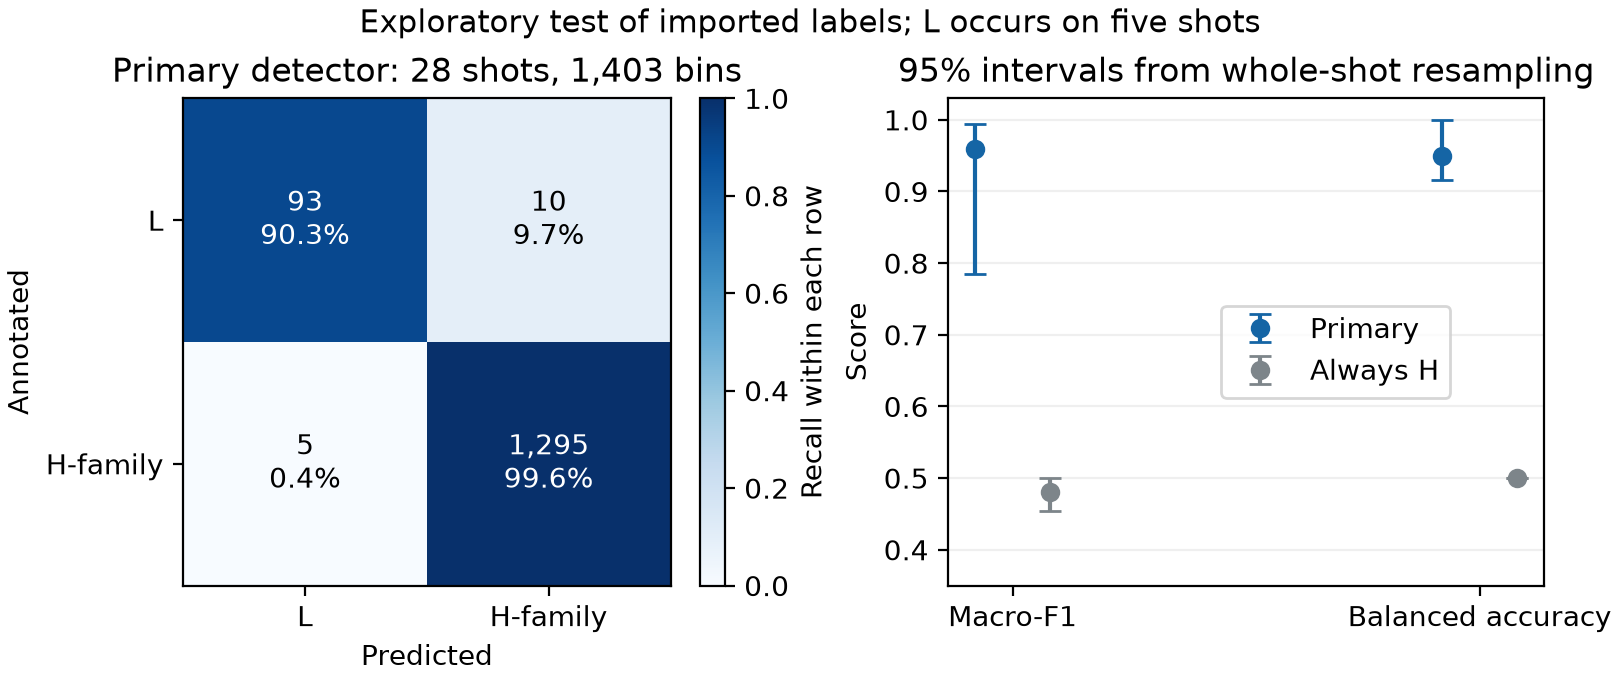

In [8]:
evaluation = json.loads((run_dir / "evaluation.json").read_text())
training = json.loads((run_dir / "training.json").read_text())
assert evaluation["freeze_sha256"] == digest(run_dir / "training.json")
assert evaluation["predictions_sha256"] == digest(run_dir / "predictions.csv")
records = []
for name, result in evaluation["models"].items():
    if name == "four_class":
        continue
    m, support = result["metrics"], result["support"]
    records.append({"model": name, "shots": support["shots"], "bins": support["bins"],
                    "F1_L": m["per_class"]["L"]["f1"],
                    "F1_H": m["per_class"]["H"]["f1"],
                    "macro_F1": m["macro_f1"], "balanced_accuracy": m["balanced_accuracy"]})
display(pd.DataFrame(records).round(4))
ci = evaluation["paired_bootstrap"]["full_cohort"]
print("Two-class bootstrap valid:", ci["nondegenerate_repetitions"], "/", ci["requested_repetitions"])
print("F1_L 95% interval:", ci["metric_95ci"]["full"]["f1_L"])
print("Original manuscript bars:", evaluation["legacy_binary_bars"])
from IPython.display import Image, display
display(Image(filename=str(run_dir / "figures/detector_results.png")))


The full versus no-BES macro-F1 paired interval includes zero, so this run
shows no incremental BES benefit. BES-only has a different eligible cohort;
comparisons must use its saved common-bin bootstrap. The four-class baseline
has only two QH and four WP test shots, and its interval is conditional on shot
resamples containing every class. No independent gold evaluation or automatic
promotion of the existing detector follows from these scores.


In [9]:
four = evaluation["models"]["four_class"]
display(pd.DataFrame(four["metrics"]["per_class"]).T.round(4))
print("Four-class macro-F1:", four["metrics"]["macro_f1"])
print("Four-class shot-bootstrap:", four["shot_bootstrap"])


,support,precision,recall,f1
L,103.0,0.9872,0.7476,0.8508
H,1167.0,0.9771,0.9871,0.9821
QH,37.0,0.6346,0.8919,0.7416
WP,94.0,0.8152,0.7979,0.8065


Four-class macro-F1: 0.8452376406484066
Four-class shot-bootstrap: {'unit': 'shot', 'requested_repetitions': 2000, 'complete_class_repetitions': 1760, 'policy': 'CI conditions on bootstrap draws containing all four reference classes; incomplete draws excluded and counted', 'metric_95ci': {'macro_f1': [0.622460309067835, 0.9280334247915433], 'balanced_accuracy': [0.6464409968363067, 0.959218707726466], 'f1_L': [0.6666666666666666, 1.0], 'precision_L': [0.6666666666666666, 1.0], 'recall_L': [0.5443181818181818, 1.0], 'f1_H': [0.9524810121025427, 0.9982609450483092], 'precision_H': [0.9248759784247136, 1.0], 'recall_H': [0.9652443274806538, 1.0], 'f1_QH': [0.4, 0.8928571428571429], 'precision_QH': [0.2857142857142857, 0.8064516129032258], 'recall_QH': [0.6666666666666666, 1.0], 'f1_WP': [0.20689655172413793, 0.9281045751633987], 'precision_WP': [0.1724137931034483, 1.0], 'recall_WP': [0.26666666666666666, 0.9038461538461539]}}


## Historical detector: insufficient common L support

Every historical train/validation shot is excluded before matching exact 50 ms
windows. Both models must have observed inputs. Only three shots / 122 bins remain,
with one L bin on one shot. All three shots were previously in the historical
model test. A perfect score on this intersection cannot establish superiority or
L generalization; a degenerate bootstrap interval adds no unseen-L-shot evidence.


In [10]:
old = json.loads((run_dir / "legacy_comparison/comparison.json").read_text())
assert old["matched_predictions_sha256"] == digest(run_dir / "legacy_comparison/matched_predictions.csv")
print("Cohort flow:", old["cohort_flow"])
print("Shared support:", old["support"])
print("Previously exposed historical test:", old["matched_shots_previously_in_historical_test"])
print("Frozen thresholds:", old["thresholds"])
print("Bootstrap interpretation:", old["bootstrap_interpretation"])


Cohort flow: {'new_diagnostic_eligible_shots': 28, 'new_diagnostic_eligible_bins': 1403, 'unseen_old_training_and_validation_shots': 8, 'unseen_old_training_and_validation_bins': 355, 'matched_observable_shots': 3, 'matched_observable_bins': 122}
Shared support: {'L': {'bins': 1, 'shots': 1}, 'H': {'bins': 121, 'shots': 3}}
Previously exposed historical test: [185915, 187036, 189602]
Frozen thresholds: {'full': 0.9635340200225744, 'legacy': 0.33, 'all_H': 0.5}
Bootstrap interpretation: Conditional resampling of observed shots only. One L bin on one shot cannot establish L generalization; degenerate perfect-score intervals do not quantify unseen L-shot uncertainty.
